Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded=files.upload()

Saving googleplaystore.csv to googleplaystore.csv
Saving googleplaystore_user_reviews.csv to googleplaystore_user_reviews.csv


In [3]:
apps = pd.read_csv("googleplaystore.csv")

reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [4]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
apps.shape

(10841, 13)

In [7]:
apps.columns


Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [8]:
# Dataset Info
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [9]:
#removing wronge Columns
apps.drop(10472, inplace=True)

In [11]:
#Convert Reviews to Integer
apps['Reviews'] = apps['Reviews'].astype(int)


Clean Installs Column



In [12]:
apps['Installs'] = apps['Installs'].str.replace('+','')
apps['Installs'] = apps['Installs'].str.replace(',','')
apps['Installs'] = apps['Installs'].astype(int)

Clean Price Column

In [13]:
apps['Price'] = apps['Price'].str.replace('$','')
apps['Price'] = apps['Price'].astype(float)

In [15]:
#checking the null values
apps.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,0
Genres,0


Cleaning the Dataset

In [16]:
#Handle Rating Missing Values
apps['Rating'].fillna(apps['Rating'].mean(), inplace=True)

In [17]:
#Now Check Dataset Again
apps.describe()

,Rating,Reviews,Installs,Price
count,10840.000000,1.084000e+04,1.084000e+04,10840.000000
mean,4.191757,4.441529e+05,1.546434e+07,1.027368
std,0.478907,2.927761e+06,8.502936e+07,15.949703
min,1.000000,0.000000e+00,0.000000e+00,0.000000
25%,4.100000,3.800000e+01,1.000000e+03,0.000000
50%,4.200000,2.094000e+03,1.000000e+05,0.000000
75%,4.500000,5.477550e+04,5.000000e+06,0.000000
max,5.000000,7.815831e+07,1.000000e+09,400.000000


1. Rating Distribution

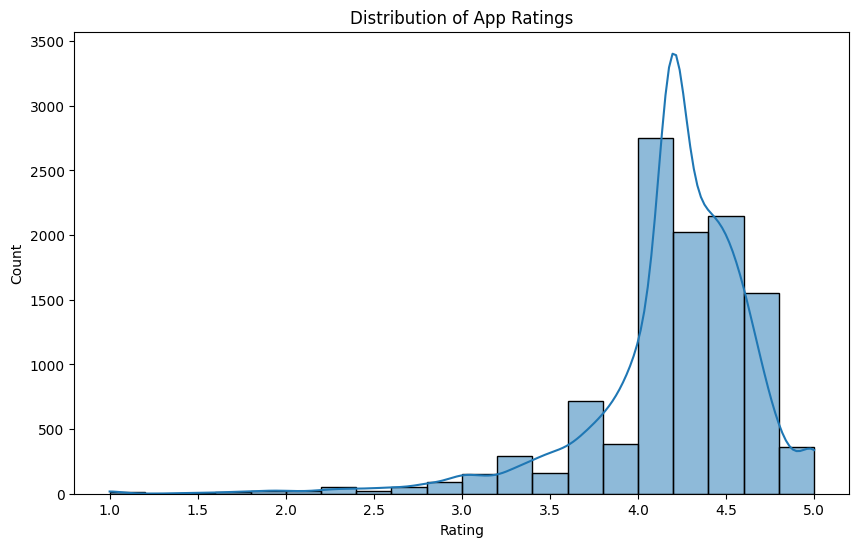

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(apps['Rating'], bins=20, kde=True)

plt.title("Distribution of App Ratings")

plt.show()

Most apps have ratings between 4.0 and 4.5, indicating generally positive user feedback

2. Apps Count by Category

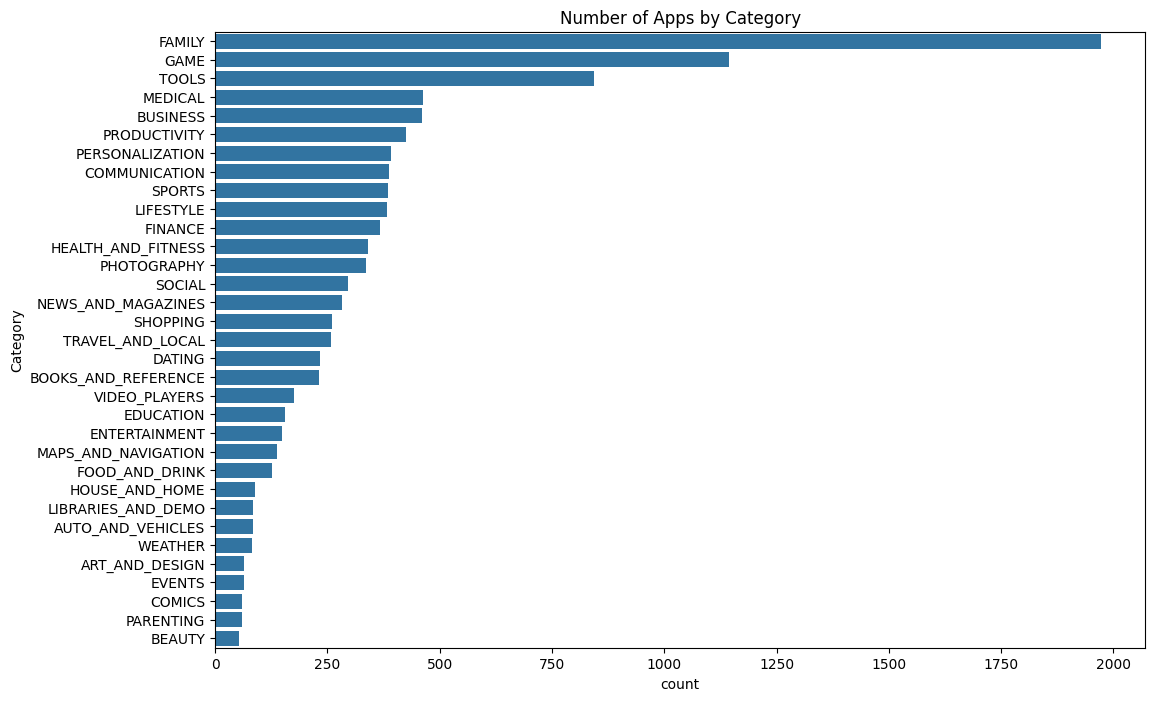

In [19]:
plt.figure(figsize=(12,8))

sns.countplot(y='Category', data=apps,
order=apps['Category'].value_counts().index)

plt.title("Number of Apps by Category")

plt.show()

Categories such as Family, Game, and Tools contain the highest number of apps.

3. Relationship Between Installs and Ratings

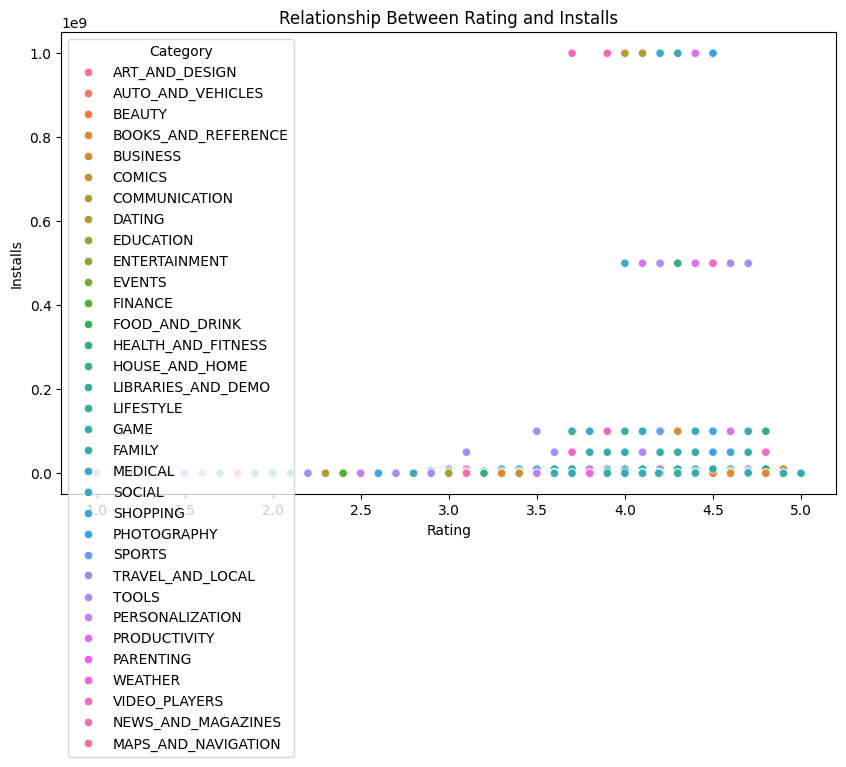

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Rating', y='Installs',
hue='Category', data=apps)

plt.title("Relationship Between Rating and Installs")

plt.show()

Apps with higher ratings generally tend to have more installations, although popularity also depends on category.

4. Top 10 Most Installed Apps

In [21]:
top_apps = apps[['App','Installs']].sort_values(by='Installs', ascending=False).head(10)

top_apps

,App,Installs
2808,Google Photos,1000000000
2853,Google Photos,1000000000
3223,Maps - Navigate & Explore,1000000000
3117,Maps - Navigate & Explore,1000000000
3234,Google,1000000000
3232,Google Street View,1000000000
3127,Google Street View,1000000000
2554,Google+,1000000000
464,Hangouts,1000000000
468,Skype - free IM & video calls,1000000000


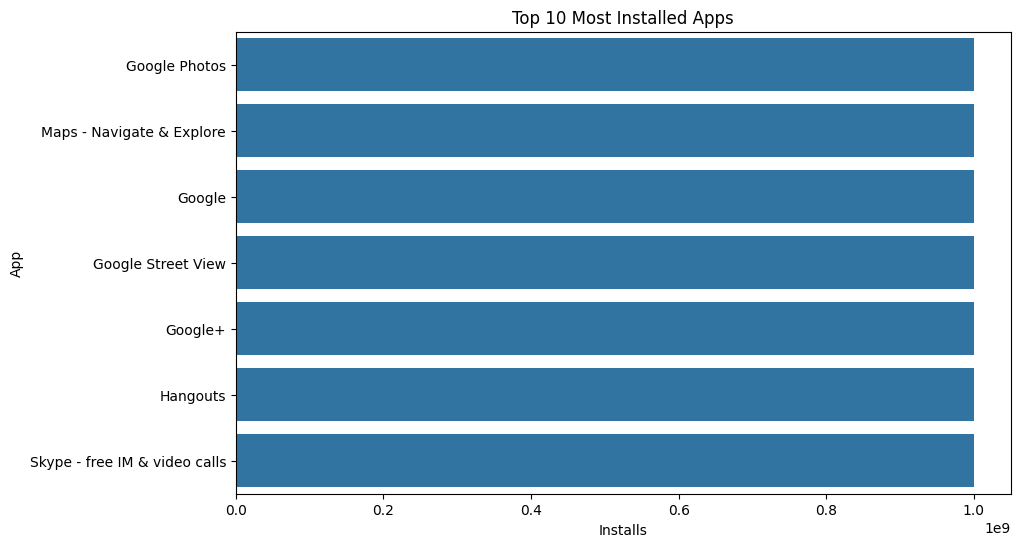

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(x='Installs', y='App', data=top_apps)

plt.title("Top 10 Most Installed Apps")

plt.show()

Global apps such as Google services and social media apps dominate the install counts.

5. Top Genres

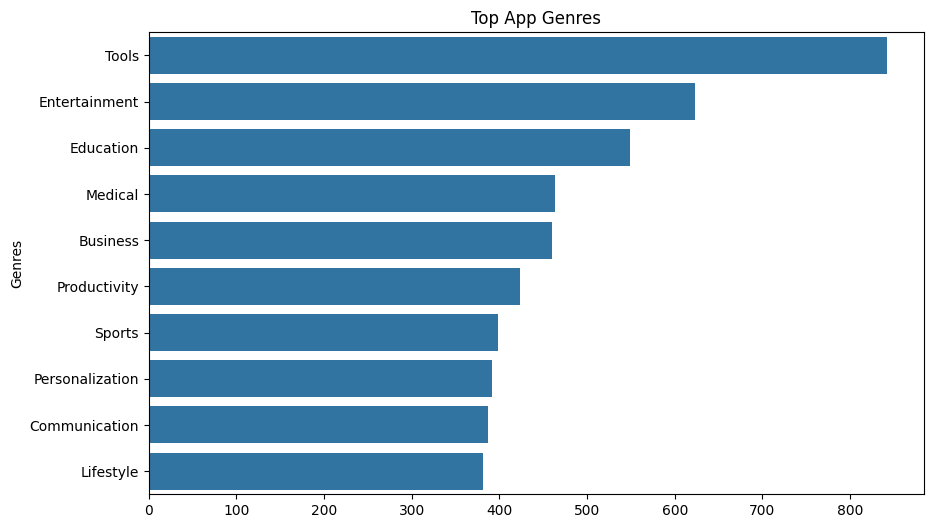

In [23]:
top_genres = apps['Genres'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top App Genres")

plt.show()

Certain genres dominate the Play Store, showing strong demand in specific categories.

6. Correlation Heatmap

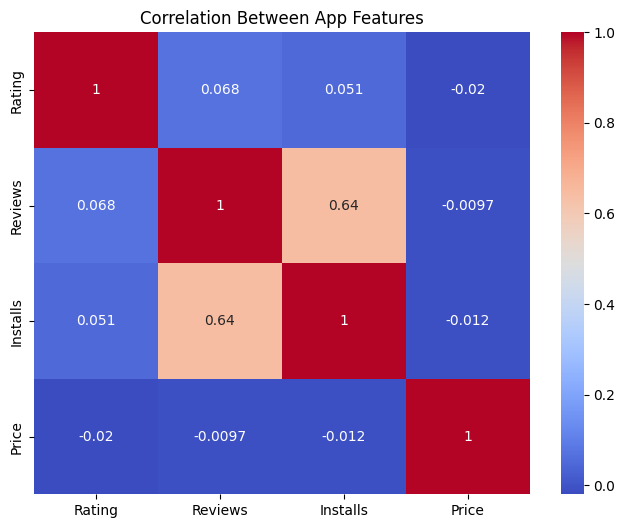

In [24]:
plt.figure(figsize=(8,6))

corr = apps.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between App Features")

plt.show()

The heatmap shows relationships between numerical features such as installs, reviews, and ratings.

**Check Reviews Dataset**

In [25]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [26]:
reviews.shape

(64295, 5)

In [27]:
reviews.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [29]:
#Remove Missing Reviews
reviews.dropna(inplace=True)

In [30]:
reviews.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


1. Sentiment Distribution

In [31]:
reviews['Sentiment'].value_counts()

,count
Sentiment,
Positive,23998
Negative,8271
Neutral,5158


2. Sentiment Visualization

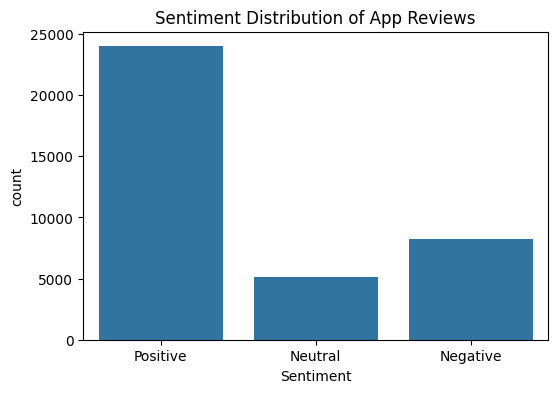

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sentiment', data=reviews)

plt.title("Sentiment Distribution of App Reviews")

plt.show()

Most user reviews are positive, indicating that users generally have a favorable opinion about apps on the Play Store.

3. Average Sentiment by App

In [33]:
sentiment_by_app = reviews.groupby('App')['Sentiment_Polarity'].mean().sort_values(ascending=False)

sentiment_by_app.head(10)

,Sentiment_Polarity
App,
HomeWork,1.000000
Google Slides,0.933333
Daily Workouts - Exercise Fitness Routine Trainer,0.800000
Bed Time Fan - White Noise Sleep Sounds,0.781250
Cameringo Lite. Filters Camera,0.770269
Google Primer,0.750000
GPS Map Free,0.700000
GPS Speedometer and Odometer,0.687500
Best Ovulation Tracker Fertility Calendar App Glow,0.595313


4. Merge Both Datasets

In [34]:
merged_df = pd.merge(apps, reviews, on="App")

In [35]:
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I hate,Negative,-0.800,0.900000


6. Rating vs Sentiment

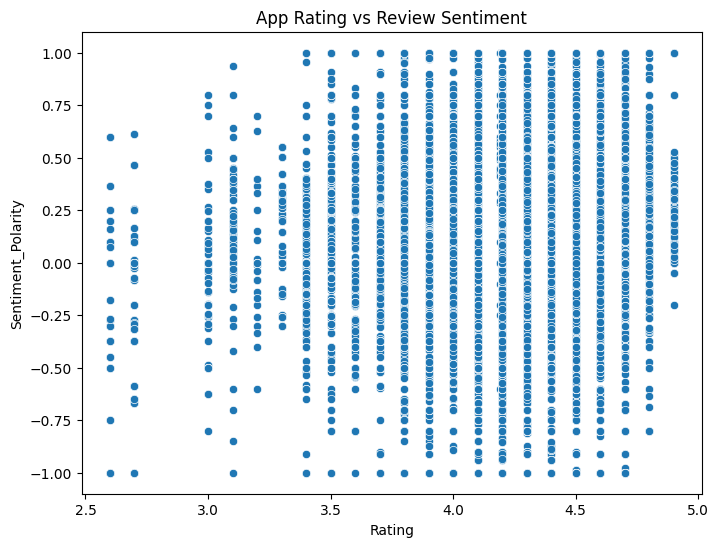

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Rating', y='Sentiment_Polarity', data=merged_df)

plt.title("App Rating vs Review Sentiment")

plt.show()

Apps with higher ratings tend to have more positive sentiment in user reviews

Conclusion

• Most apps on the Google Play Store have ratings above 4.0.

• Categories such as Family, Game, and Tools dominate the Play Store.

• Apps with higher installs generally have more reviews.

• Sentiment analysis shows that the majority of user reviews are positive.

• Ratings and sentiment polarity show a positive relationship.